# __Plotting system wavefunctions__ - using energy levels obtained from solvers

In [4]:
from QuantumMST import scatterer, protein_structure, Solvers, plot_wavefunction, generate_system, generate_periodic

Following a similar workflow to earlier, we define the selected system and compute the energy levels using the solvers demonstrated previously.

In [5]:
system2 = protein_structure(reference_system = 1)

rA, VA, xA = 0.8, -5, -1
rB, VB, RAB = 0.6, -6, 2

s1 = scatterer(r=rA, V=VA)
s2 = scatterer(rB, VB)
s3 = scatterer(r=rA-0.1, V=VB-1)

system4 = protein_structure(scatterers = [s1, s3, s2, s1], positions =  [xA, xA+RAB, xA+2*RAB, xA+2*RAB+3])

system21 = protein_structure(reference_system = 5)


In [6]:
results2 = Solvers(system2, mode='numpy', nE=20)
results4 = Solvers(system4, mode='numpy', nE=100)
results21 = Solvers(system21, mode='numpy', nE=100)

In [7]:
print(f"System 2:{results2}\nSystem 4:{results4}\nSystem 21:{results21}")


System 2:[-3.94981791 -3.22848707]
System 4:[-5.07775698 -3.71908005 -3.47302993 -3.35599824]
System 21:[-3.94430155 -3.60875158 -2.96874429 -2.1277341  -1.90742184 -1.11671865
 -1.02815544 -0.72405081 -0.37937668 -0.27311058]


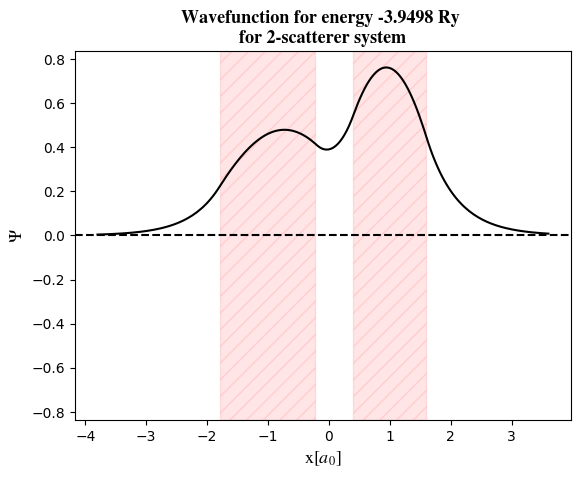

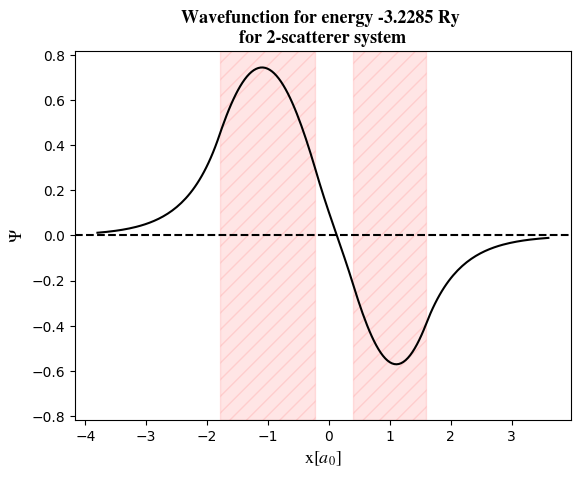

In [8]:
for e in results2:
    system2.energy = e
    V, array_x = system2.potential()
    plot_wavefunction(array_x, V, system2)

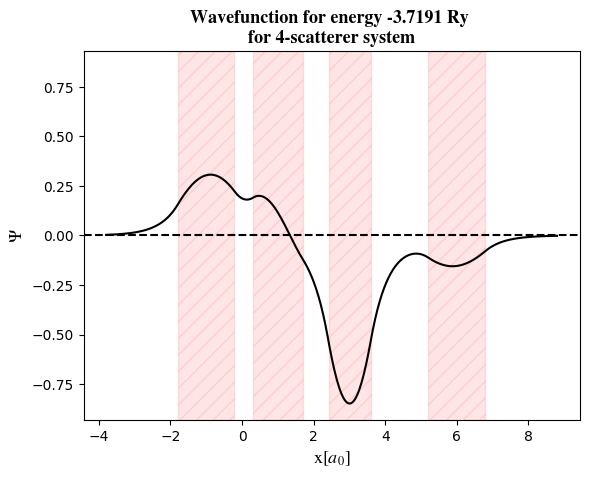

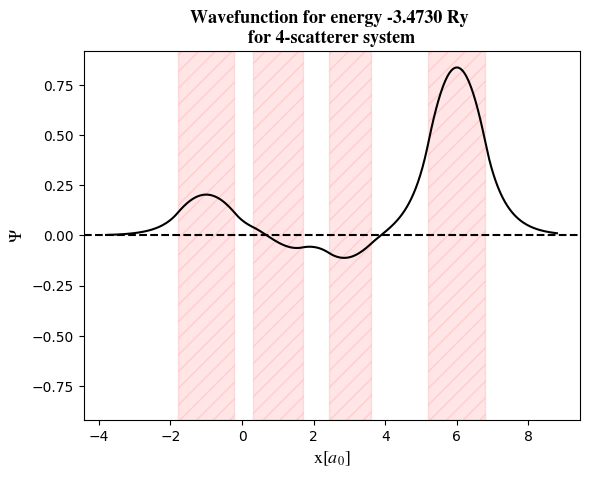

In [9]:
for e in [results4[1], results4[2]]:
    system4.energy = e
    V, array_x = system4.potential()
    plot_wavefunction(array_x, V, system4)

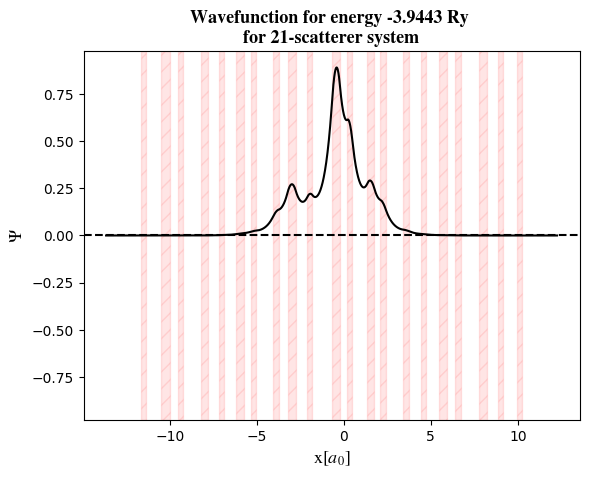

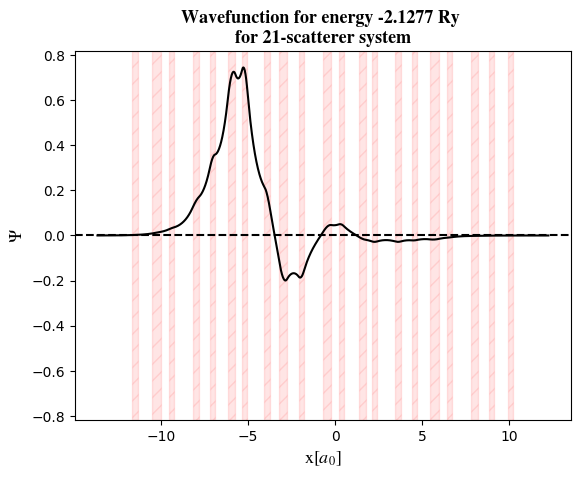

In [16]:
for e in [results21[0], results21[3]]:
    system21.energy = e
    V, array_x = system21.potential()
    plot_wavefunction(array_x, V, system21)

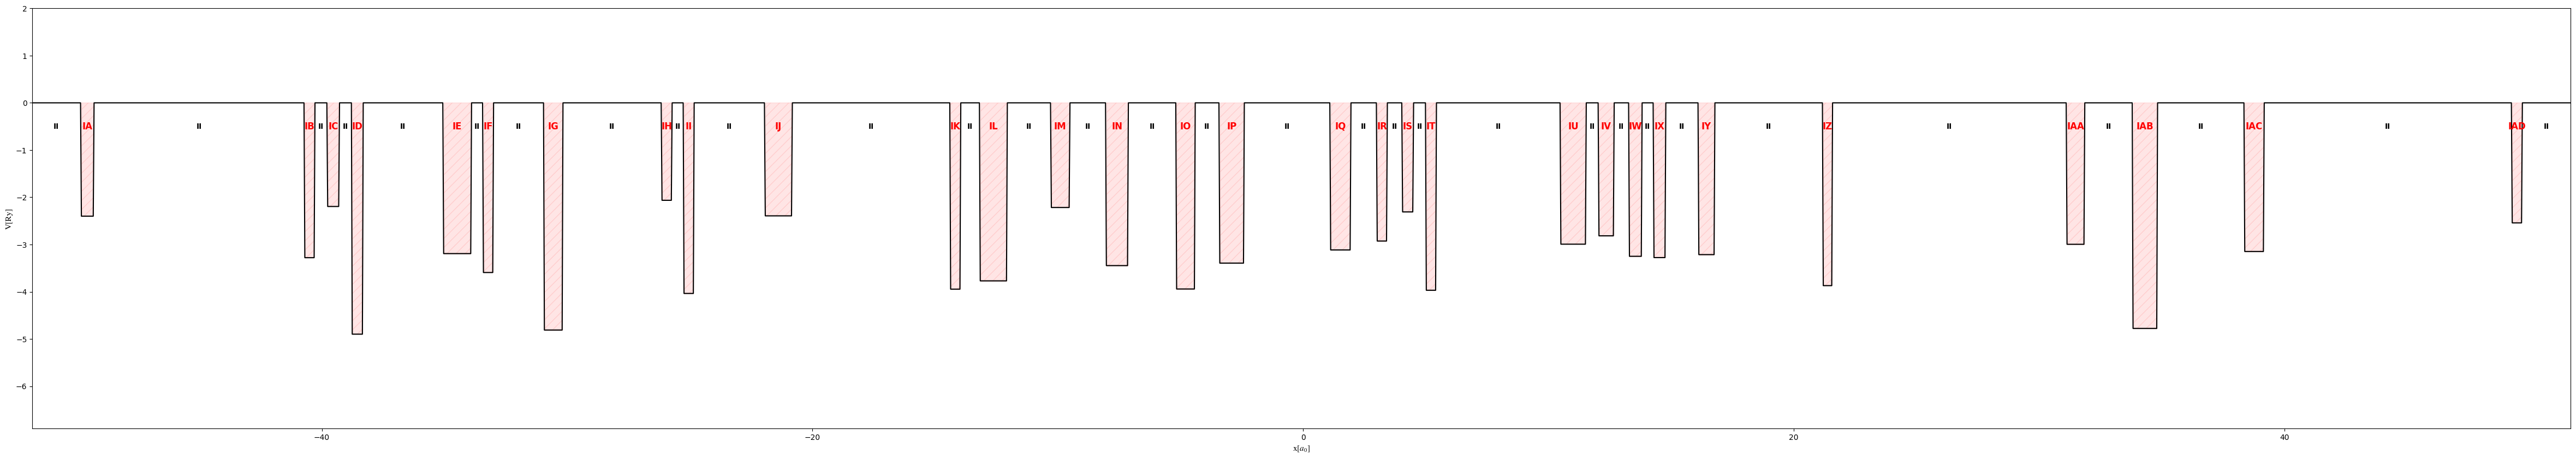

In [18]:
s, positions = generate_system(
    number=30,
    min_dist_pot=0.5,
    rmin=0.2,
    rmax=0.6,       
    Vmin=-5.0,
    Vmax=-2.0,      
    xmin=-50,
    xmax=50
)
system_random = protein_structure(scatterers = s, positions = positions)
system_random.potential()
plot_potential(system_random)
results_random = Solvers(system_random, mode='numpy', nE=100)

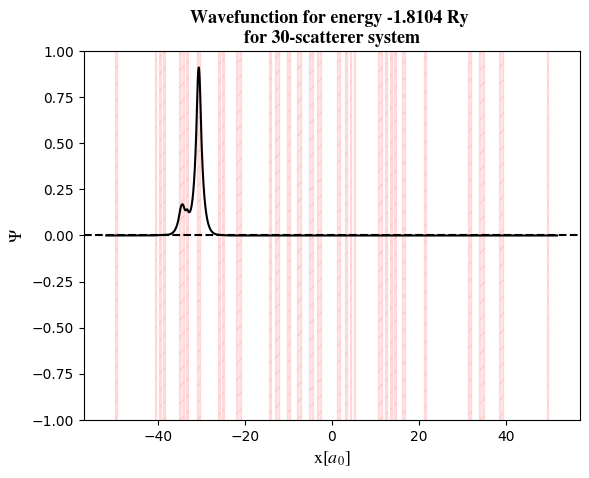

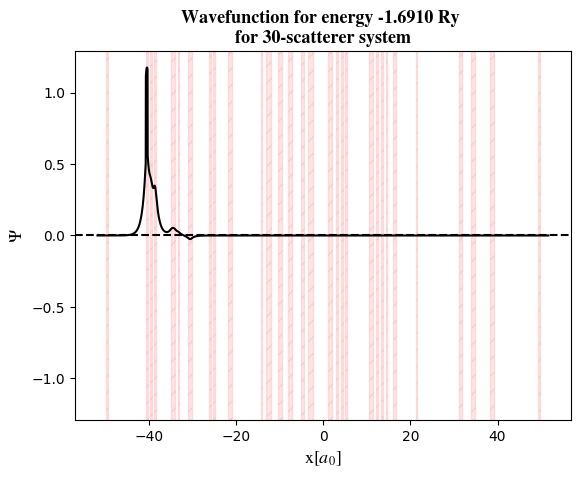

In [22]:
for e in [results_random[2], results_random[3]]:
    system_random.energy = e
    V, array_x = system_random.potential()
    plot_wavefunction(array_x, V, system_random)

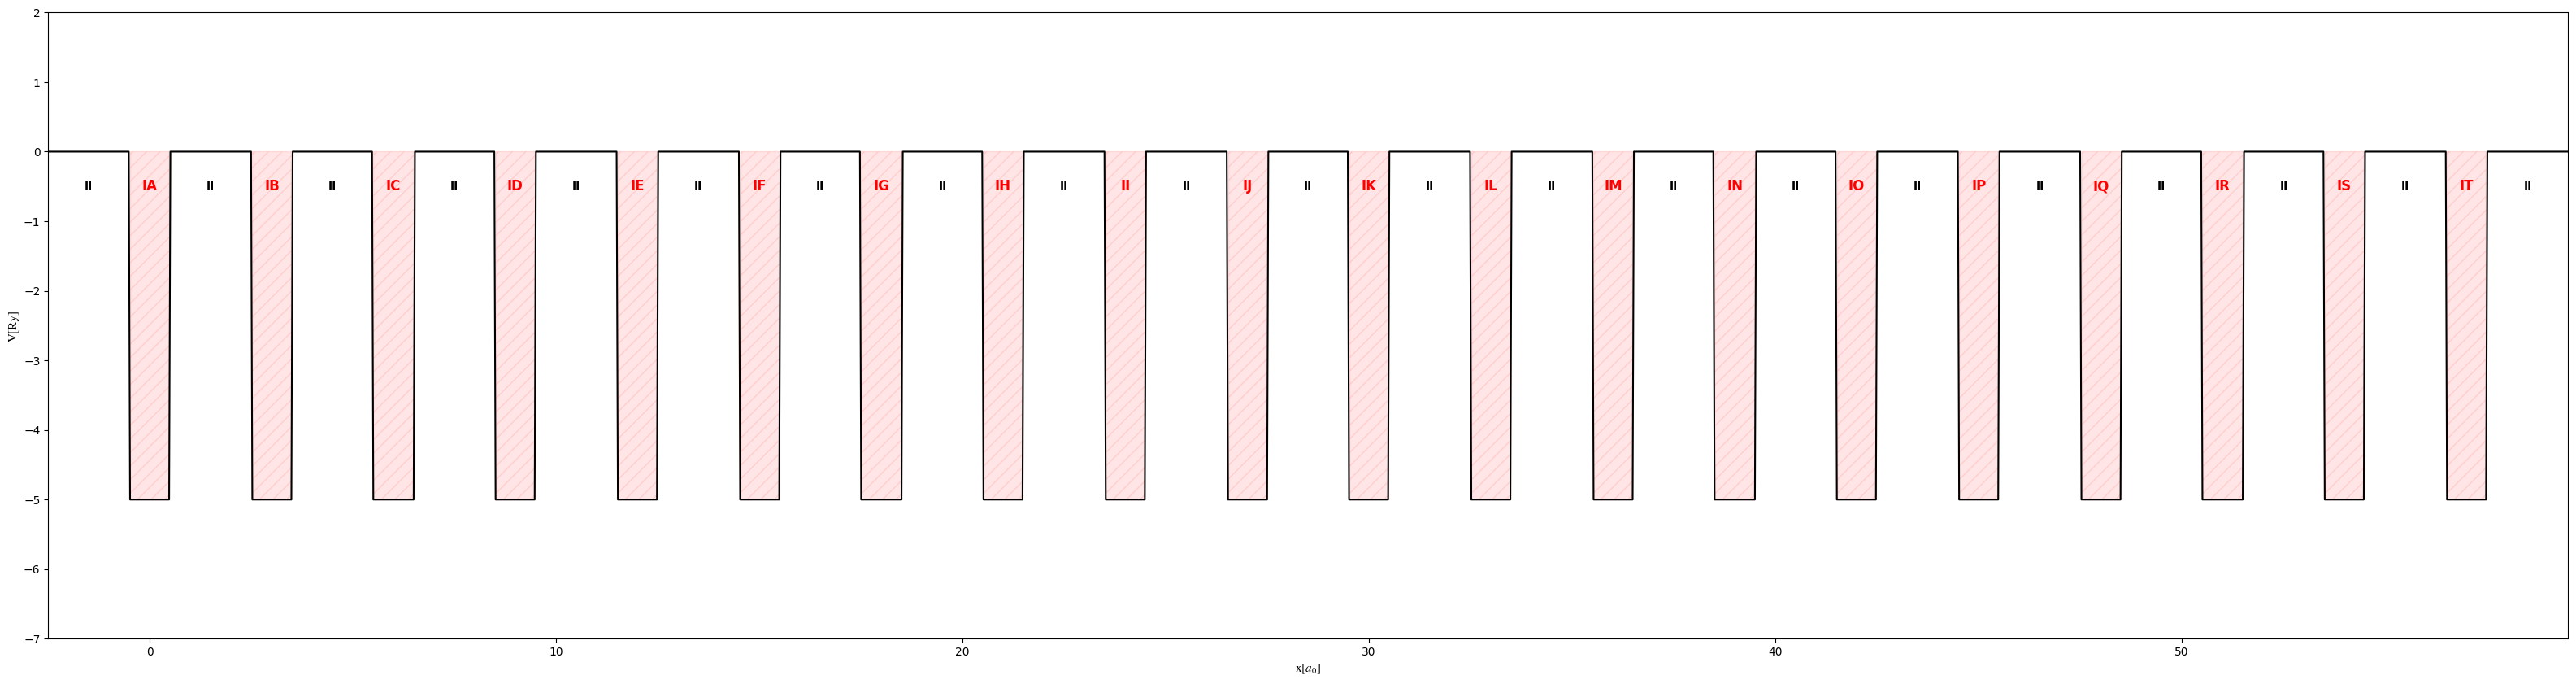

In [14]:
s, positions = generate_periodic(number=20, dis=3.0, r=0.5, V=-5.0)
system_periodic = protein_structure(scatterers = s, positions = positions)
system_periodic.potential()
plot_potential(system_periodic)
results_periodic = Solvers(system_periodic, mode='numpy', nE=100)

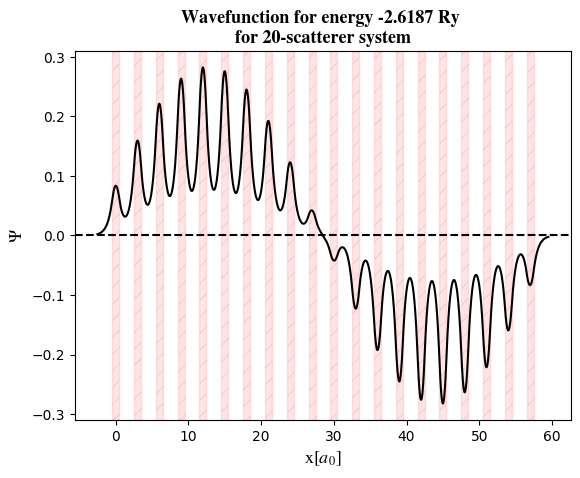

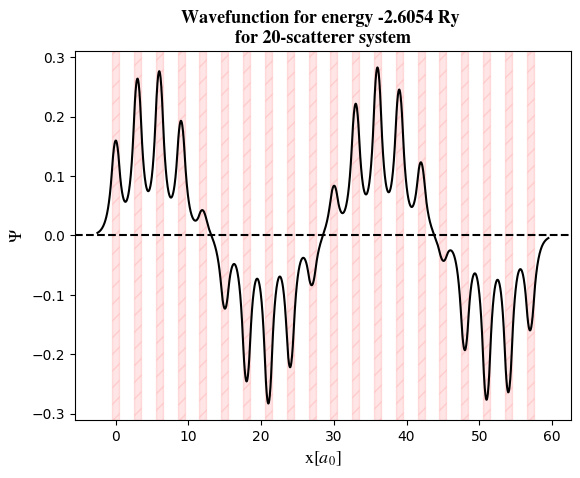

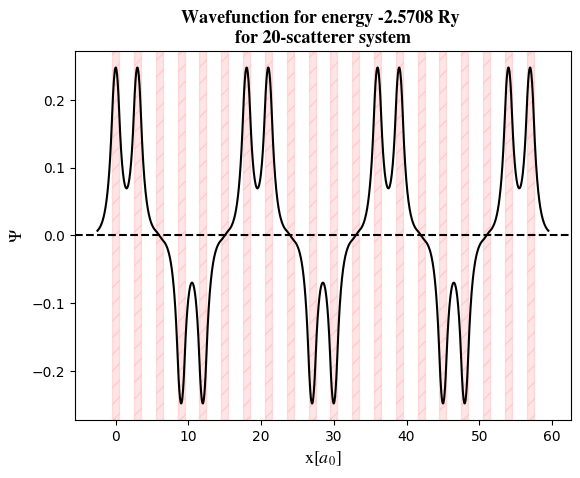

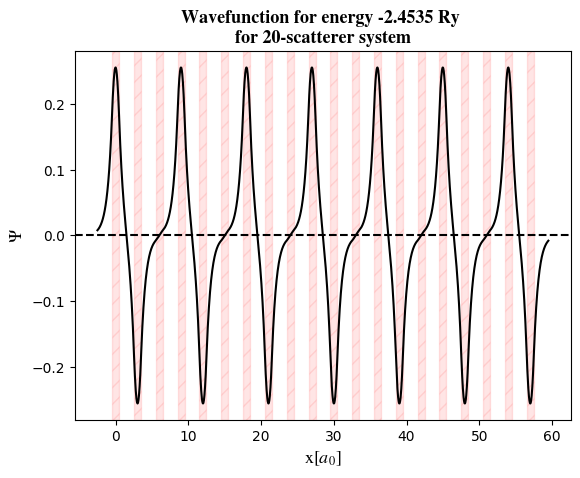

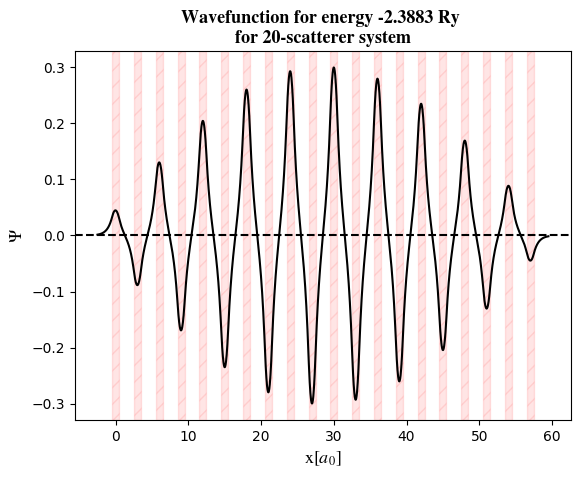

In [15]:
for e in [results_periodic[1], results_periodic[3], results_periodic[6], results_periodic[13], results_periodic[-1]]:
    system_periodic.energy = e
    V, array_x = system_periodic.potential()
    plot_wavefunction(array_x, V, system_periodic)

    